# $\xi=0.05$


Found 7 unique jump types:

Damage jumps:
  Damage (λ3=0.0): 236 paths
  Damage (λ3=0.083): 225 paths
  Damage (λ3=0.167): 241 paths
  Damage (λ3=0.25): 283 paths
  Damage (λ3=0.333): 265 paths

Tech jumps:
  Interm: 8281 paths
  Post: 361 paths

damage_0.0: Sampled 5 paths from 236

damage_0.083: Sampled 5 paths from 225

damage_0.167: Sampled 5 paths from 241

damage_0.25: Sampled 5 paths from 283

damage_0.333: Sampled 5 paths from 265

tech_interm: Sampled 5 paths from 8281

tech_post: Sampled 5 paths from 361

Plotting control paths for each jump type...

Plotting damage_0.0...
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/controls_paths_damage_0.0.png


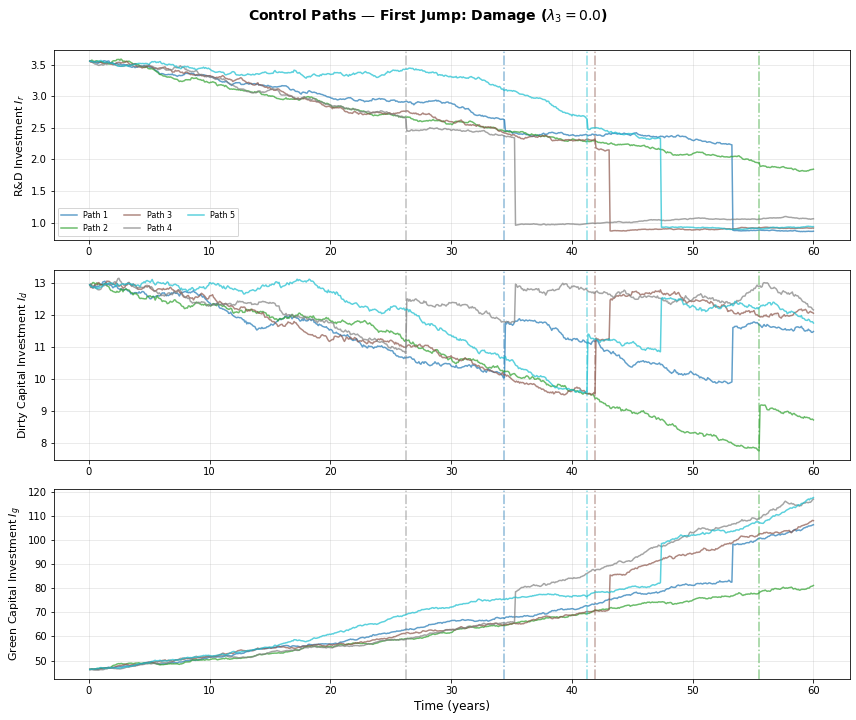


Plotting damage_0.083...
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/controls_paths_damage_0.083.png


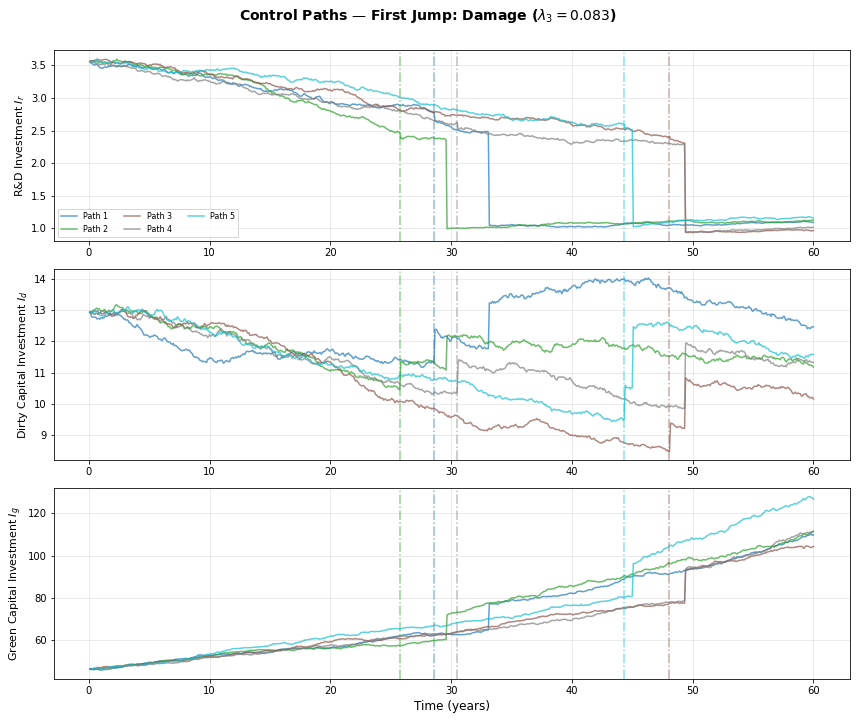


Plotting damage_0.167...
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/controls_paths_damage_0.167.png


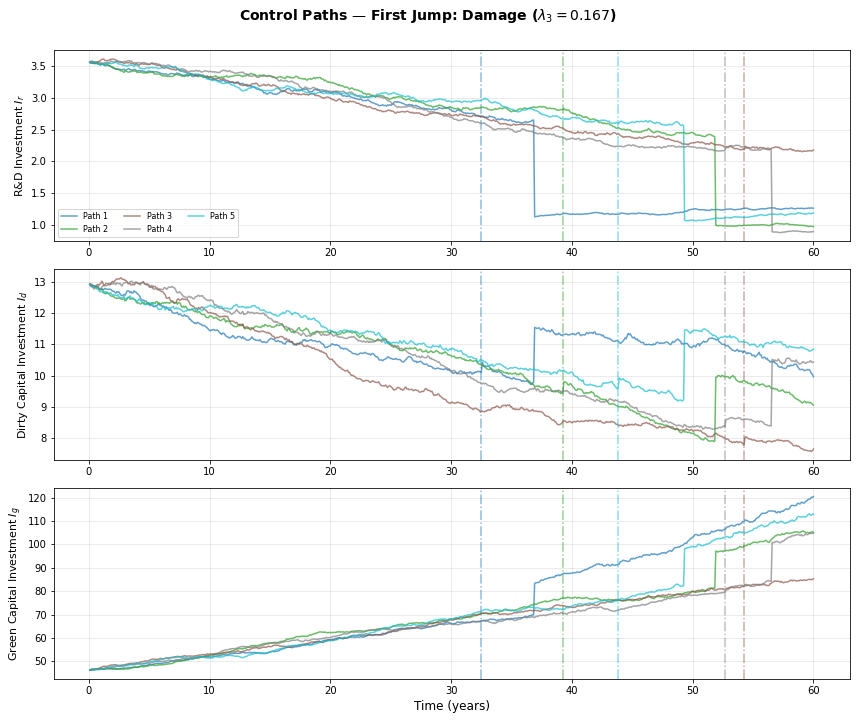


Plotting damage_0.25...
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/controls_paths_damage_0.25.png


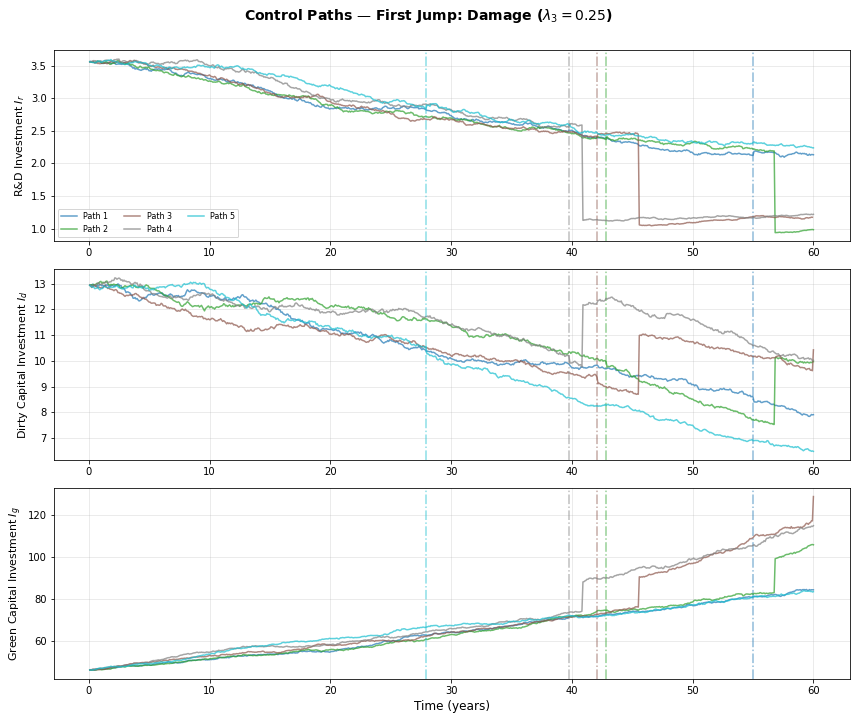


Plotting damage_0.333...
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/controls_paths_damage_0.333.png


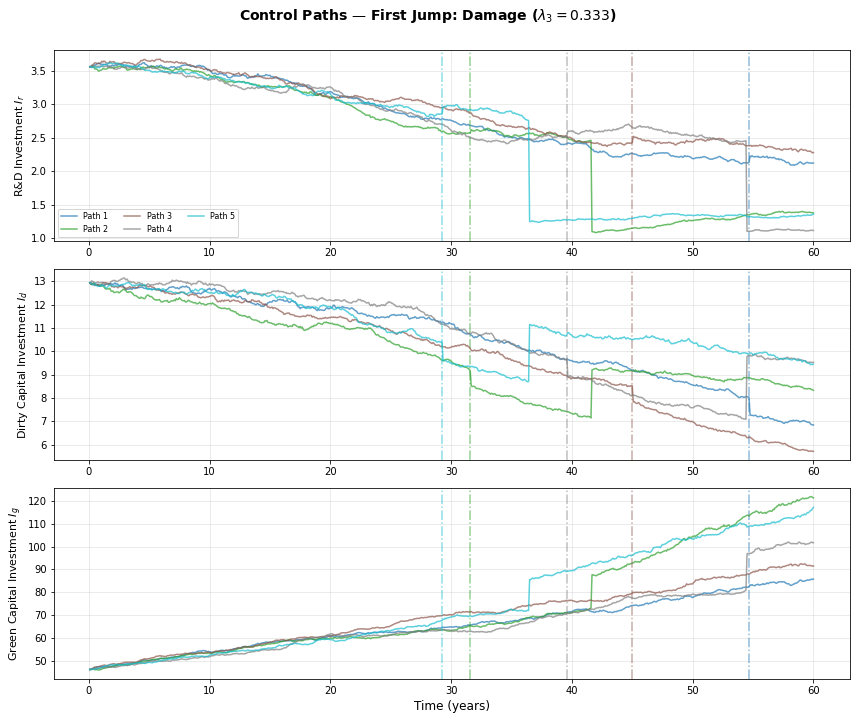


Plotting tech_interm...
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/controls_paths_tech_interm.png


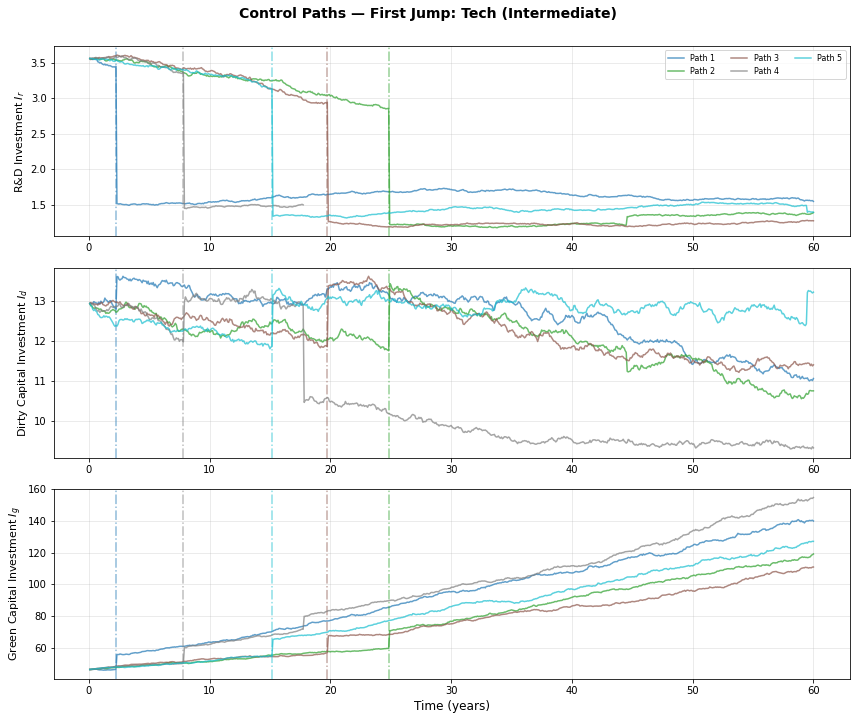


Plotting tech_post...
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05/controls_paths_tech_post.png


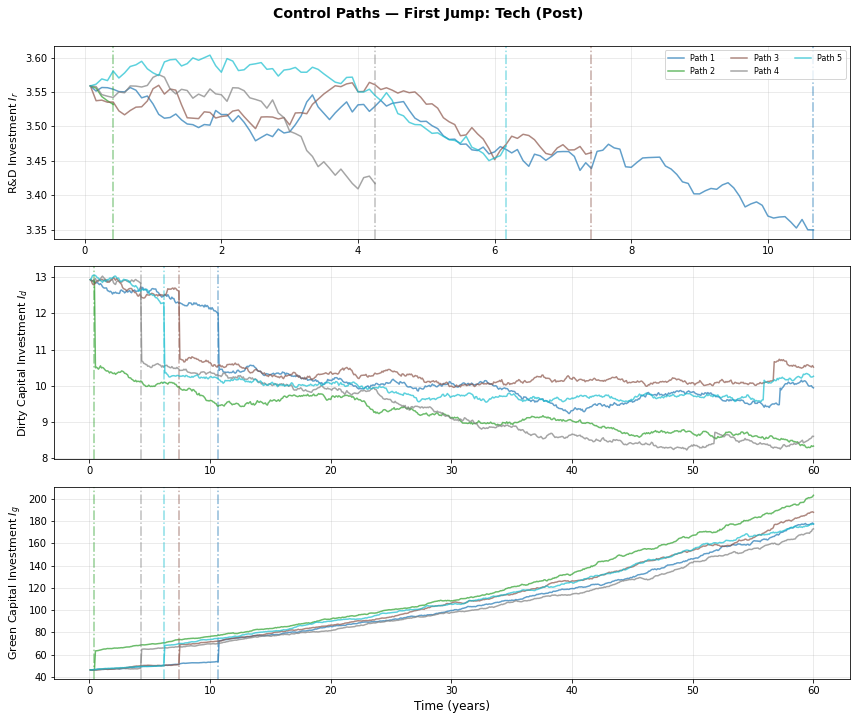


All plots complete!


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ---------- CONFIG ----------
base_folder = "/project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.05"
seed_min, seed_max = 1, 100
save_fig = True
LAMBDA3_ROUND = 3          # round λ3 values to group close floats
N_PATHS_PER_TYPE = 5     # number of paths to plot per jump type
# ----------------------------

def load_arrays(folder, seed):
    """Load all necessary arrays for a given seed."""
    D   = np.load(os.path.join(folder, f"damage_state_array_{seed}.npy"))
    T   = np.load(os.path.join(folder, f"tech_state_array_{seed}.npy"))
    Ir  = np.load(os.path.join(folder, f"I_r_array_{seed}.npy"))
    Id  = np.load(os.path.join(folder, f"I_d_array_{seed}.npy"))
    Ig  = np.load(os.path.join(folder, f"I_g_array_{seed}.npy"))
    G3  = np.load(os.path.join(folder, f"gamma3_array_{seed}.npy"))
    return D, T, Ir, Id, Ig, G3

# Collect paths grouped by first jump type
# Jump types: 
#   - 'damage_X.XXX' for damage jumps (5 types based on λ3)
#   - 'tech_interm' for tech jump 0→1
#   - 'tech_post' for tech jump 0→2
paths_by_jump_type = defaultdict(list)

print("Collecting paths and identifying first jumps...")
for seed in range(seed_min, seed_max + 1):
    try:
        D, T, Ir, Id, Ig, G3 = load_arrays(base_folder, seed)
    except FileNotFoundError:
        print(f"[Seed {seed:03d}] missing files, skipping.")
        continue

    n_paths, T_len = D.shape
    
    for path_idx in range(n_paths):
        d = D[path_idx]
        t = T[path_idx]
        
        # Find first damage jump (0 → 1)
        damage_trans = np.where((d[:-1] == 0) & (d[1:] == 1))[0]
        first_damage_time = damage_trans[0] + 1 if damage_trans.size > 0 else np.inf
        
        # Find first tech jump (0 → 1 or 0 → 2)
        tech_trans = np.where((t[:-1] == 0) & (t[1:] > 0))[0]
        first_tech_time = tech_trans[0] + 1 if tech_trans.size > 0 else np.inf
        
        # Determine which jump comes first
        if first_damage_time == np.inf and first_tech_time == np.inf:
            continue  # No jumps in this path
        
        if first_damage_time < first_tech_time:
            # Damage jump comes first
            jump_time = int(first_damage_time)
            lam = G3[path_idx, jump_time]
            
            if not np.isfinite(lam):
                continue
            
            lam_key = round(float(lam), LAMBDA3_ROUND) if LAMBDA3_ROUND is not None else float(lam)
            jump_type = f"damage_{lam_key}"
            
        elif first_tech_time < first_damage_time:
            # Tech jump comes first
            jump_time = int(first_tech_time)
            tech_state_after = t[jump_time]
            
            if tech_state_after == 1:
                jump_type = "tech_interm"
            elif tech_state_after == 2:
                jump_type = "tech_post"
            else:
                continue  # Unexpected state
        else:
            continue  # Should not happen
        
        # Store the full control paths
        paths_by_jump_type[jump_type].append({
            'seed': seed,
            'path_idx': path_idx,
            'jump_time': jump_time,
            'jump_type': jump_type,
            'Ir': Ir[path_idx, :],
            'Id': Id[path_idx, :],
            'Ig': Ig[path_idx, :]
        })

# Sort jump types (damage types by λ3, then tech types)
damage_types = sorted([k for k in paths_by_jump_type.keys() if k.startswith('damage_')])
tech_types = sorted([k for k in paths_by_jump_type.keys() if k.startswith('tech_')])
all_jump_types = damage_types + tech_types

print(f"\nFound {len(all_jump_types)} unique jump types:")
print("\nDamage jumps:")
for jt in damage_types:
    lam_val = jt.replace('damage_', '')
    print(f"  Damage (λ3={lam_val}): {len(paths_by_jump_type[jt])} paths")
print("\nTech jumps:")
for jt in tech_types:
    print(f"  {jt.replace('tech_', '').capitalize()}: {len(paths_by_jump_type[jt])} paths")

# Sample paths for plotting
np.random.seed(42)  # For reproducibility
sampled_paths = {}

for jump_type in all_jump_types:
    available = paths_by_jump_type[jump_type]
    n_available = len(available)
    
    if n_available <= N_PATHS_PER_TYPE:
        sampled_paths[jump_type] = available
        print(f"\n{jump_type}: Using all {n_available} paths")
    else:
        indices = np.random.choice(n_available, N_PATHS_PER_TYPE, replace=False)
        sampled_paths[jump_type] = [available[i] for i in indices]
        print(f"\n{jump_type}: Sampled {N_PATHS_PER_TYPE} paths from {n_available}")

# Plotting function - now plots all three controls in subplots
def plot_all_controls(jump_type, paths, time_step=1/12):
    """
    Plot all three controls (Ir, Id, Ig) for the same paths in subplots.
    
    Parameters:
    - jump_type: str, type of jump
    - paths: list of path dictionaries
    - time_step: float, time step in years (default 1/12 for monthly)
    """
    
    if len(paths) == 0:
        return
    
    # Create figure with 3 subplots
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    
    # Color map for different paths
    colors = plt.cm.tab10(np.linspace(0, 1, len(paths)))
    
    control_keys = ['Ir', 'Id', 'Ig']
    control_names = ['R&D Investment $I_r$', 
                     'Dirty Capital Investment $I_d$', 
                     'Green Capital Investment $I_g$']
    
    for ax_idx, (control_key, control_name) in enumerate(zip(control_keys, control_names)):
        ax = axes[ax_idx]
        
        for i, path_data in enumerate(paths):
            control_path = path_data[control_key]
            jump_time = path_data['jump_time']
            
            # Create time axis in years
            T_len = len(control_path)
            time_years = np.arange(T_len) * time_step
            
            # Plot the control path
            ax.plot(time_years, control_path, 
                   alpha=0.7, linewidth=1.5, color=colors[i],
                   label=f"Path {i+1}")
            
            # Add vertical dot-dash line at jump time
            jump_time_years = jump_time * time_step
            ax.axvline(x=jump_time_years, color=colors[i], 
                      linestyle='-.', linewidth=1.5, alpha=0.5)
        
        ax.set_ylabel(control_name, fontsize=11)
        ax.grid(True, alpha=0.3)
        
        # Only show legend on first subplot
        if ax_idx == 0:
            ax.legend(loc='best', fontsize=8, ncol=3)
        
        # Only show x-label on bottom subplot
        if ax_idx == 2:
            ax.set_xlabel("Time (years)", fontsize=12)
    
    # Create title based on jump type
    if jump_type.startswith('damage_'):
        lam_val = jump_type.replace('damage_', '')
        title = f"Control Paths — First Jump: Damage ($\lambda_3 = {lam_val}$)"
    elif jump_type == 'tech_interm':
        title = "Control Paths — First Jump: Tech (Intermediate)"
    elif jump_type == 'tech_post':
        title = "Control Paths — First Jump: Tech (Post)"
    else:
        title = f"Control Paths — First Jump: {jump_type}"
    
    fig.suptitle(title, fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    
    if save_fig:
        filename = f"controls_paths_{jump_type}.png"
        out_path = os.path.join(base_folder, filename)
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {out_path}")
    
    plt.show()
    plt.close()

# Plot for each jump type
print("\n" + "="*60)
print("Plotting control paths for each jump type...")
print("="*60)

for jump_type in all_jump_types:
    if jump_type in sampled_paths:
        print(f"\nPlotting {jump_type}...")
        plot_all_controls(jump_type, sampled_paths[jump_type])

print("\nAll plots complete!")

# $\xi=0.1$


Found 7 unique jump types:

Damage jumps:
  Damage (λ3=0.0): 265 paths
  Damage (λ3=0.083): 283 paths
  Damage (λ3=0.167): 258 paths
  Damage (λ3=0.25): 270 paths
  Damage (λ3=0.333): 215 paths

Tech jumps:
  Interm: 8264 paths
  Post: 326 paths

damage_0.0: Sampled 5 paths from 265

damage_0.083: Sampled 5 paths from 283

damage_0.167: Sampled 5 paths from 258

damage_0.25: Sampled 5 paths from 270

damage_0.333: Sampled 5 paths from 215

tech_interm: Sampled 5 paths from 8264

tech_post: Sampled 5 paths from 326

Plotting control paths for each jump type...

Plotting damage_0.0...
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/controls_paths_damage_0.0.png


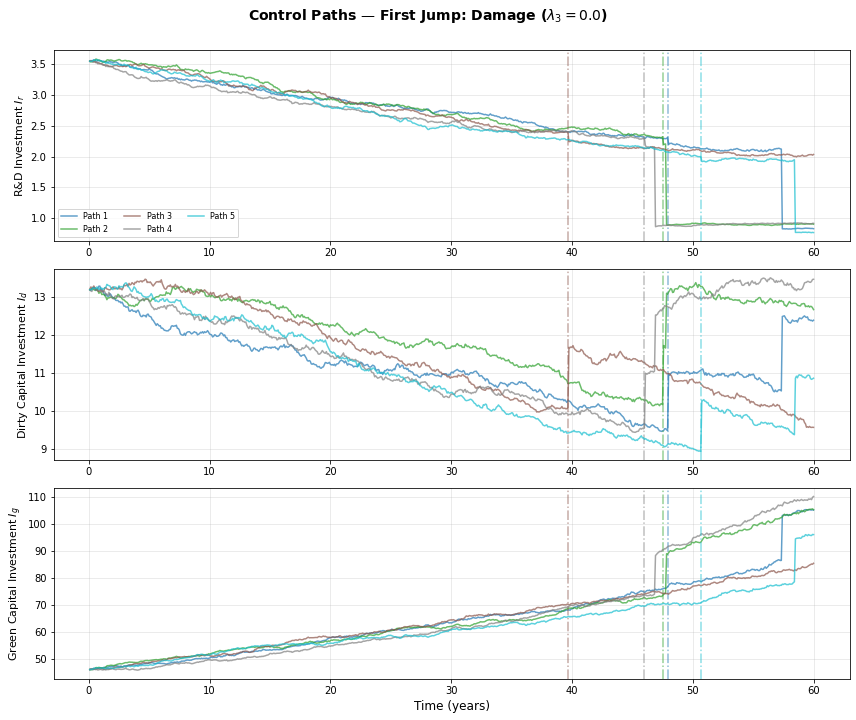


Plotting damage_0.083...
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/controls_paths_damage_0.083.png


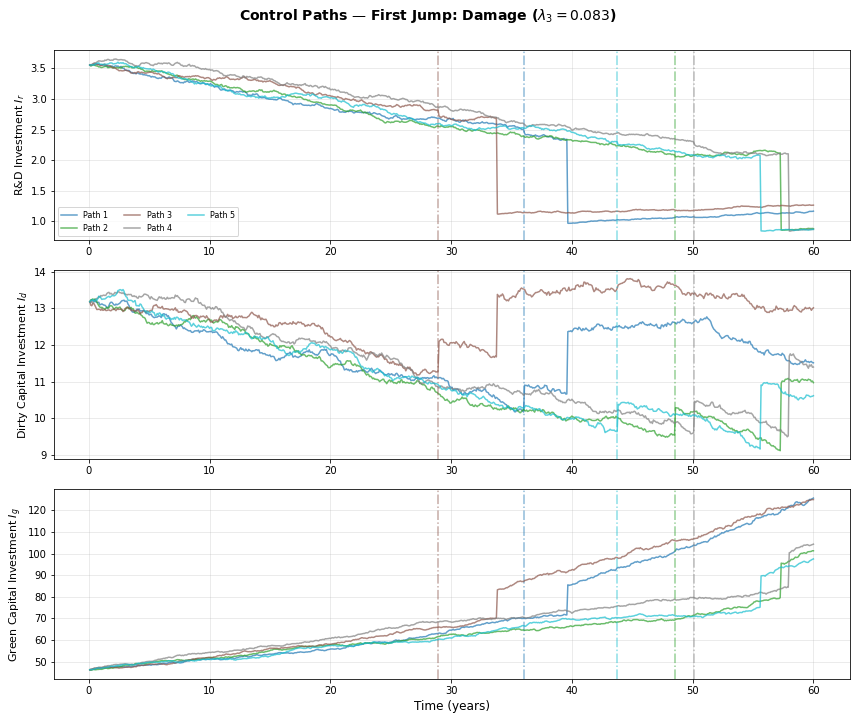


Plotting damage_0.167...
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/controls_paths_damage_0.167.png


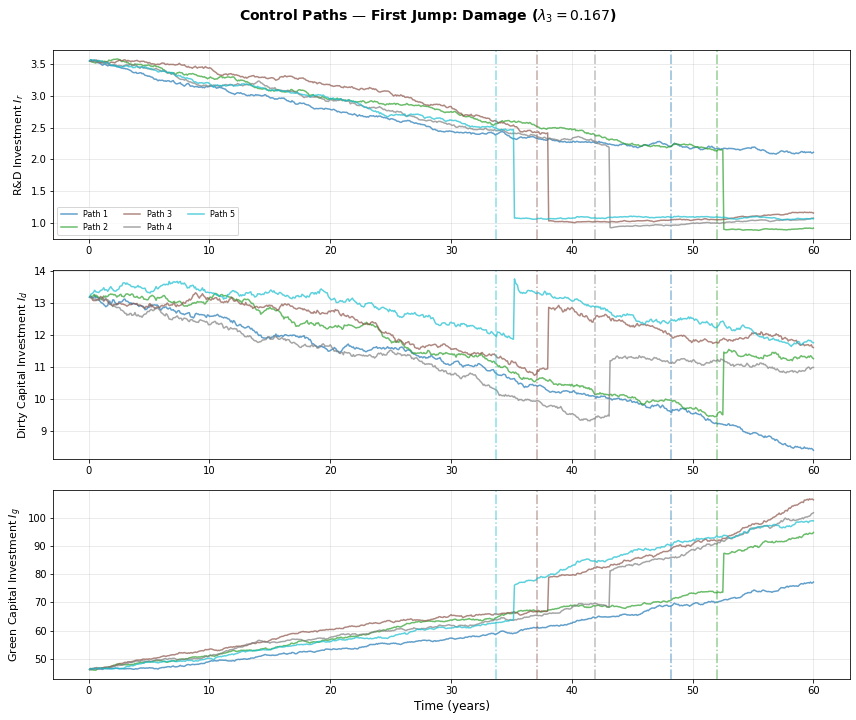


Plotting damage_0.25...
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/controls_paths_damage_0.25.png


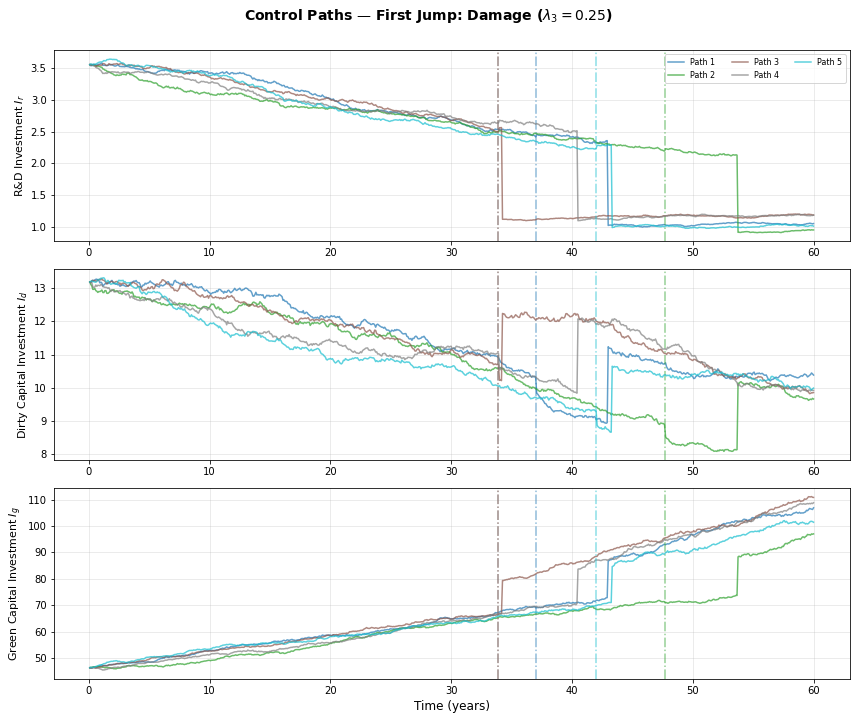


Plotting damage_0.333...
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/controls_paths_damage_0.333.png


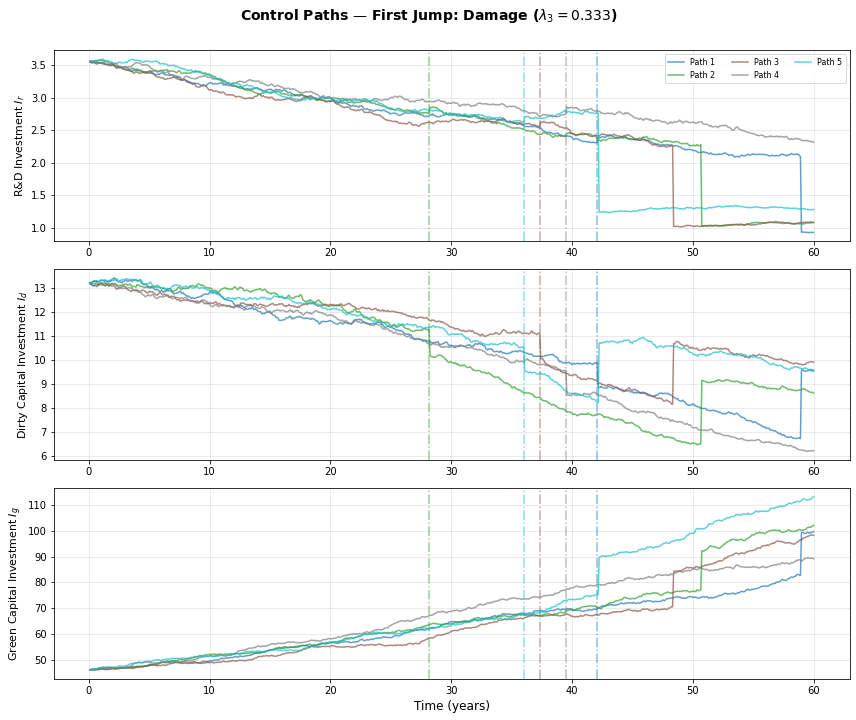


Plotting tech_interm...
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/controls_paths_tech_interm.png


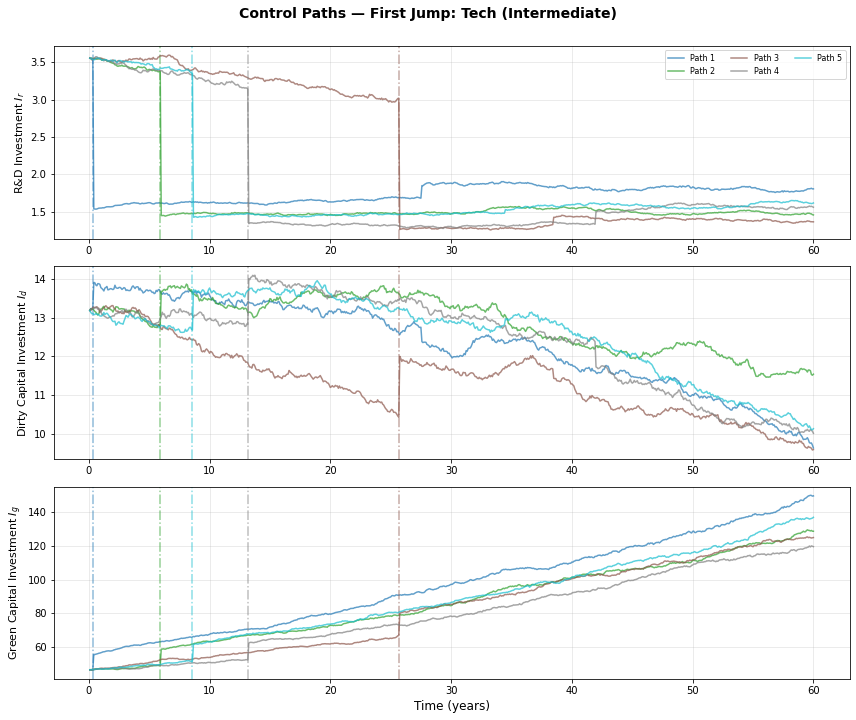


Plotting tech_post...
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1/controls_paths_tech_post.png


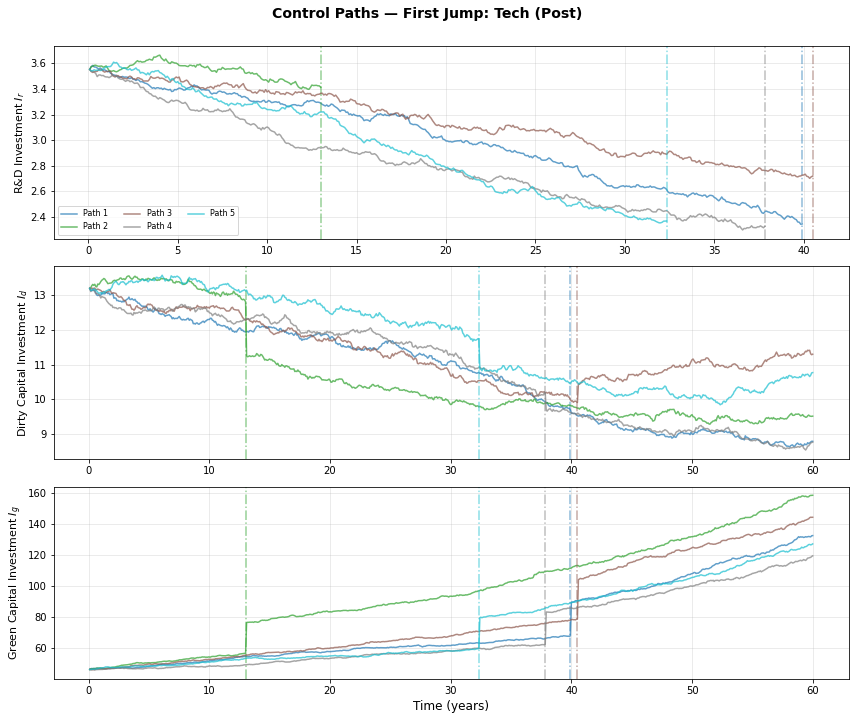


All plots complete!


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ---------- CONFIG ----------
base_folder = "/project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.1"
seed_min, seed_max = 1, 100
save_fig = True
LAMBDA3_ROUND = 3          # round λ3 values to group close floats
N_PATHS_PER_TYPE = 5     # number of paths to plot per jump type
# ----------------------------

def load_arrays(folder, seed):
    """Load all necessary arrays for a given seed."""
    D   = np.load(os.path.join(folder, f"damage_state_array_{seed}.npy"))
    T   = np.load(os.path.join(folder, f"tech_state_array_{seed}.npy"))
    Ir  = np.load(os.path.join(folder, f"I_r_array_{seed}.npy"))
    Id  = np.load(os.path.join(folder, f"I_d_array_{seed}.npy"))
    Ig  = np.load(os.path.join(folder, f"I_g_array_{seed}.npy"))
    G3  = np.load(os.path.join(folder, f"gamma3_array_{seed}.npy"))
    return D, T, Ir, Id, Ig, G3

# Collect paths grouped by first jump type
# Jump types: 
#   - 'damage_X.XXX' for damage jumps (5 types based on λ3)
#   - 'tech_interm' for tech jump 0→1
#   - 'tech_post' for tech jump 0→2
paths_by_jump_type = defaultdict(list)

print("Collecting paths and identifying first jumps...")
for seed in range(seed_min, seed_max + 1):
    try:
        D, T, Ir, Id, Ig, G3 = load_arrays(base_folder, seed)
    except FileNotFoundError:
        print(f"[Seed {seed:03d}] missing files, skipping.")
        continue

    n_paths, T_len = D.shape
    
    for path_idx in range(n_paths):
        d = D[path_idx]
        t = T[path_idx]
        
        # Find first damage jump (0 → 1)
        damage_trans = np.where((d[:-1] == 0) & (d[1:] == 1))[0]
        first_damage_time = damage_trans[0] + 1 if damage_trans.size > 0 else np.inf
        
        # Find first tech jump (0 → 1 or 0 → 2)
        tech_trans = np.where((t[:-1] == 0) & (t[1:] > 0))[0]
        first_tech_time = tech_trans[0] + 1 if tech_trans.size > 0 else np.inf
        
        # Determine which jump comes first
        if first_damage_time == np.inf and first_tech_time == np.inf:
            continue  # No jumps in this path
        
        if first_damage_time < first_tech_time:
            # Damage jump comes first
            jump_time = int(first_damage_time)
            lam = G3[path_idx, jump_time]
            
            if not np.isfinite(lam):
                continue
            
            lam_key = round(float(lam), LAMBDA3_ROUND) if LAMBDA3_ROUND is not None else float(lam)
            jump_type = f"damage_{lam_key}"
            
        elif first_tech_time < first_damage_time:
            # Tech jump comes first
            jump_time = int(first_tech_time)
            tech_state_after = t[jump_time]
            
            if tech_state_after == 1:
                jump_type = "tech_interm"
            elif tech_state_after == 2:
                jump_type = "tech_post"
            else:
                continue  # Unexpected state
        else:
            continue  # Should not happen
        
        # Store the full control paths
        paths_by_jump_type[jump_type].append({
            'seed': seed,
            'path_idx': path_idx,
            'jump_time': jump_time,
            'jump_type': jump_type,
            'Ir': Ir[path_idx, :],
            'Id': Id[path_idx, :],
            'Ig': Ig[path_idx, :]
        })

# Sort jump types (damage types by λ3, then tech types)
damage_types = sorted([k for k in paths_by_jump_type.keys() if k.startswith('damage_')])
tech_types = sorted([k for k in paths_by_jump_type.keys() if k.startswith('tech_')])
all_jump_types = damage_types + tech_types

print(f"\nFound {len(all_jump_types)} unique jump types:")
print("\nDamage jumps:")
for jt in damage_types:
    lam_val = jt.replace('damage_', '')
    print(f"  Damage (λ3={lam_val}): {len(paths_by_jump_type[jt])} paths")
print("\nTech jumps:")
for jt in tech_types:
    print(f"  {jt.replace('tech_', '').capitalize()}: {len(paths_by_jump_type[jt])} paths")

# Sample paths for plotting
np.random.seed(42)  # For reproducibility
sampled_paths = {}

for jump_type in all_jump_types:
    available = paths_by_jump_type[jump_type]
    n_available = len(available)
    
    if n_available <= N_PATHS_PER_TYPE:
        sampled_paths[jump_type] = available
        print(f"\n{jump_type}: Using all {n_available} paths")
    else:
        indices = np.random.choice(n_available, N_PATHS_PER_TYPE, replace=False)
        sampled_paths[jump_type] = [available[i] for i in indices]
        print(f"\n{jump_type}: Sampled {N_PATHS_PER_TYPE} paths from {n_available}")

# Plotting function - now plots all three controls in subplots
def plot_all_controls(jump_type, paths, time_step=1/12):
    """
    Plot all three controls (Ir, Id, Ig) for the same paths in subplots.
    
    Parameters:
    - jump_type: str, type of jump
    - paths: list of path dictionaries
    - time_step: float, time step in years (default 1/12 for monthly)
    """
    
    if len(paths) == 0:
        return
    
    # Create figure with 3 subplots
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    
    # Color map for different paths
    colors = plt.cm.tab10(np.linspace(0, 1, len(paths)))
    
    control_keys = ['Ir', 'Id', 'Ig']
    control_names = ['R&D Investment $I_r$', 
                     'Dirty Capital Investment $I_d$', 
                     'Green Capital Investment $I_g$']
    
    for ax_idx, (control_key, control_name) in enumerate(zip(control_keys, control_names)):
        ax = axes[ax_idx]
        
        for i, path_data in enumerate(paths):
            control_path = path_data[control_key]
            jump_time = path_data['jump_time']
            
            # Create time axis in years
            T_len = len(control_path)
            time_years = np.arange(T_len) * time_step
            
            # Plot the control path
            ax.plot(time_years, control_path, 
                   alpha=0.7, linewidth=1.5, color=colors[i],
                   label=f"Path {i+1}")
            
            # Add vertical dot-dash line at jump time
            jump_time_years = jump_time * time_step
            ax.axvline(x=jump_time_years, color=colors[i], 
                      linestyle='-.', linewidth=1.5, alpha=0.5)
        
        ax.set_ylabel(control_name, fontsize=11)
        ax.grid(True, alpha=0.3)
        
        # Only show legend on first subplot
        if ax_idx == 0:
            ax.legend(loc='best', fontsize=8, ncol=3)
        
        # Only show x-label on bottom subplot
        if ax_idx == 2:
            ax.set_xlabel("Time (years)", fontsize=12)
    
    # Create title based on jump type
    if jump_type.startswith('damage_'):
        lam_val = jump_type.replace('damage_', '')
        title = f"Control Paths — First Jump: Damage ($\lambda_3 = {lam_val}$)"
    elif jump_type == 'tech_interm':
        title = "Control Paths — First Jump: Tech (Intermediate)"
    elif jump_type == 'tech_post':
        title = "Control Paths — First Jump: Tech (Post)"
    else:
        title = f"Control Paths — First Jump: {jump_type}"
    
    fig.suptitle(title, fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    
    if save_fig:
        filename = f"controls_paths_{jump_type}.png"
        out_path = os.path.join(base_folder, filename)
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {out_path}")
    
    plt.show()
    plt.close()

# Plot for each jump type
print("\n" + "="*60)
print("Plotting control paths for each jump type...")
print("="*60)

for jump_type in all_jump_types:
    if jump_type in sampled_paths:
        print(f"\nPlotting {jump_type}...")
        plot_all_controls(jump_type, sampled_paths[jump_type])

print("\nAll plots complete!")

# $\xi=0.3$


Found 7 unique jump types:

Damage jumps:
  Damage (λ3=0.0): 271 paths
  Damage (λ3=0.083): 254 paths
  Damage (λ3=0.167): 276 paths
  Damage (λ3=0.25): 244 paths
  Damage (λ3=0.333): 296 paths

Tech jumps:
  Interm: 8197 paths
  Post: 351 paths

damage_0.0: Sampled 5 paths from 271

damage_0.083: Sampled 5 paths from 254

damage_0.167: Sampled 5 paths from 276

damage_0.25: Sampled 5 paths from 244

damage_0.333: Sampled 5 paths from 296

tech_interm: Sampled 5 paths from 8197

tech_post: Sampled 5 paths from 351

Plotting control paths for each jump type...

Plotting damage_0.0...
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/controls_paths_damage_0.0.png


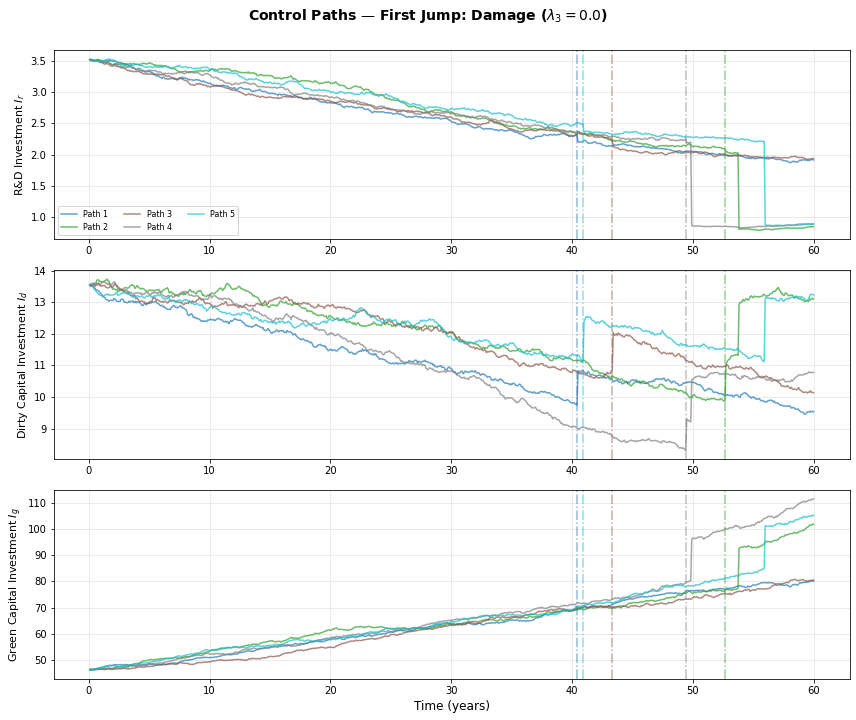


Plotting damage_0.083...
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/controls_paths_damage_0.083.png


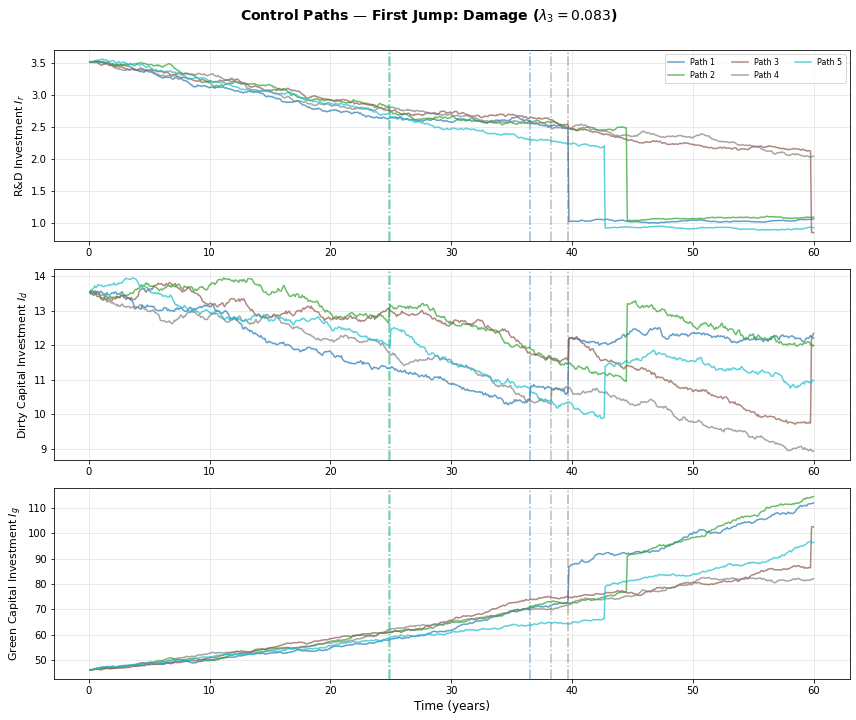


Plotting damage_0.167...
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/controls_paths_damage_0.167.png


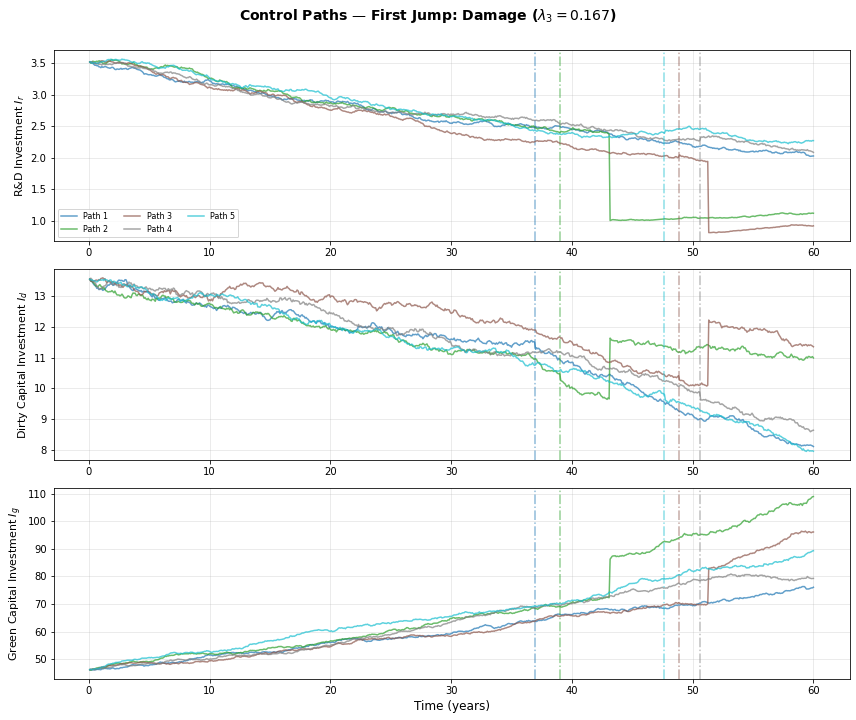


Plotting damage_0.25...
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/controls_paths_damage_0.25.png


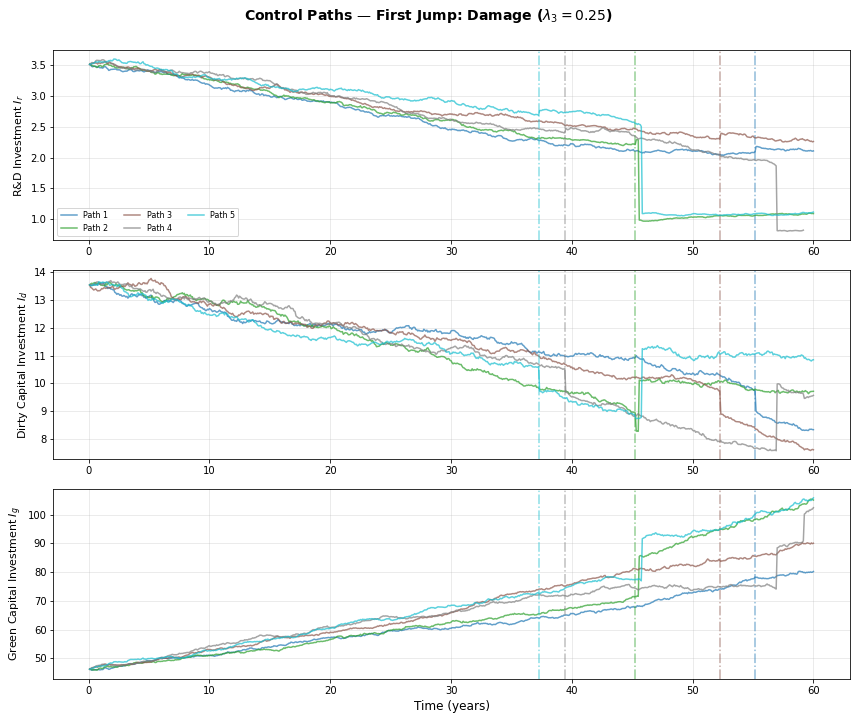


Plotting damage_0.333...
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/controls_paths_damage_0.333.png


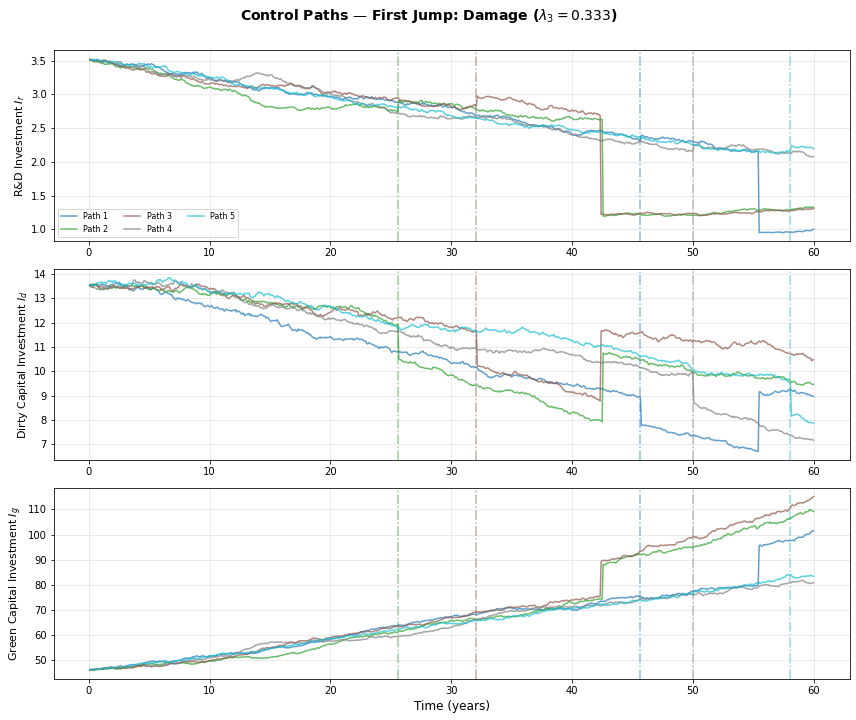


Plotting tech_interm...
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/controls_paths_tech_interm.png


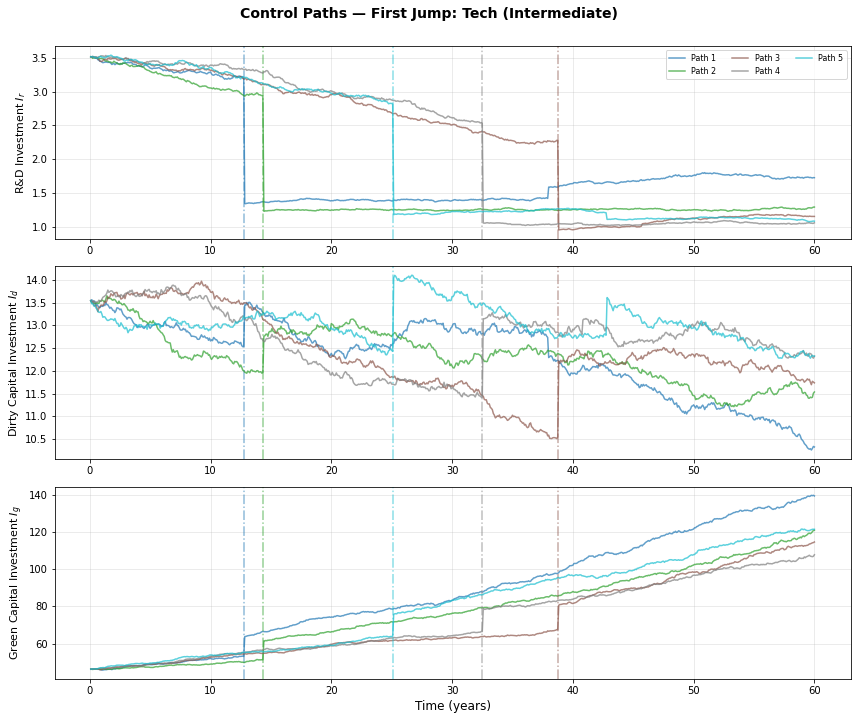


Plotting tech_post...
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3/controls_paths_tech_post.png


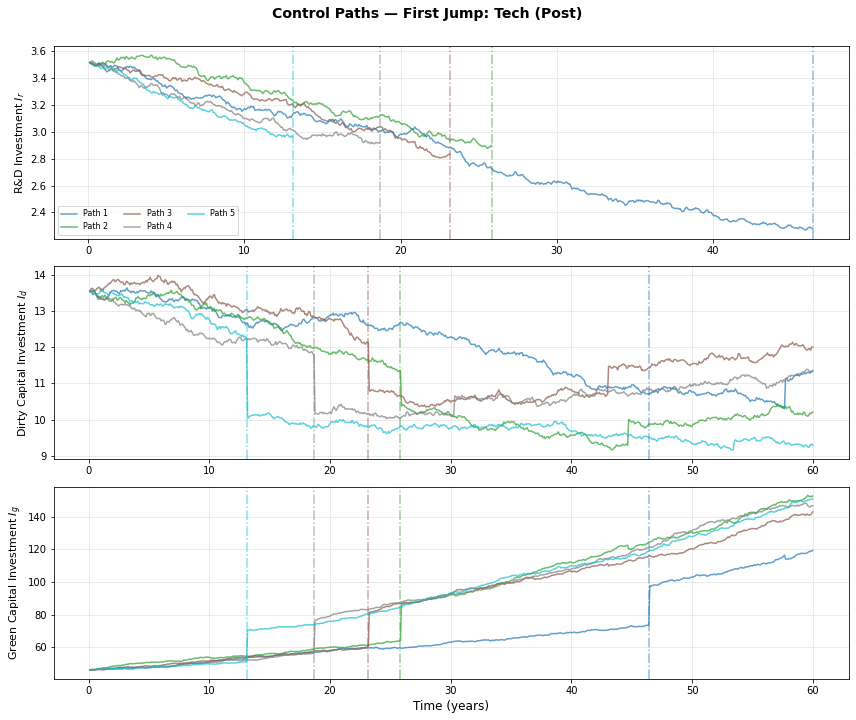


All plots complete!


In [4]:
# ---------- CONFIG ----------
base_folder = "/project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_0.3"
seed_min, seed_max = 1, 100
save_fig = True
LAMBDA3_ROUND = 3          # round λ3 values to group close floats
N_PATHS_PER_TYPE = 5     # number of paths to plot per jump type
# ----------------------------

def load_arrays(folder, seed):
    """Load all necessary arrays for a given seed."""
    D   = np.load(os.path.join(folder, f"damage_state_array_{seed}.npy"))
    T   = np.load(os.path.join(folder, f"tech_state_array_{seed}.npy"))
    Ir  = np.load(os.path.join(folder, f"I_r_array_{seed}.npy"))
    Id  = np.load(os.path.join(folder, f"I_d_array_{seed}.npy"))
    Ig  = np.load(os.path.join(folder, f"I_g_array_{seed}.npy"))
    G3  = np.load(os.path.join(folder, f"gamma3_array_{seed}.npy"))
    return D, T, Ir, Id, Ig, G3

# Collect paths grouped by first jump type
# Jump types: 
#   - 'damage_X.XXX' for damage jumps (5 types based on λ3)
#   - 'tech_interm' for tech jump 0→1
#   - 'tech_post' for tech jump 0→2
paths_by_jump_type = defaultdict(list)

print("Collecting paths and identifying first jumps...")
for seed in range(seed_min, seed_max + 1):
    try:
        D, T, Ir, Id, Ig, G3 = load_arrays(base_folder, seed)
    except FileNotFoundError:
        print(f"[Seed {seed:03d}] missing files, skipping.")
        continue

    n_paths, T_len = D.shape
    
    for path_idx in range(n_paths):
        d = D[path_idx]
        t = T[path_idx]
        
        # Find first damage jump (0 → 1)
        damage_trans = np.where((d[:-1] == 0) & (d[1:] == 1))[0]
        first_damage_time = damage_trans[0] + 1 if damage_trans.size > 0 else np.inf
        
        # Find first tech jump (0 → 1 or 0 → 2)
        tech_trans = np.where((t[:-1] == 0) & (t[1:] > 0))[0]
        first_tech_time = tech_trans[0] + 1 if tech_trans.size > 0 else np.inf
        
        # Determine which jump comes first
        if first_damage_time == np.inf and first_tech_time == np.inf:
            continue  # No jumps in this path
        
        if first_damage_time < first_tech_time:
            # Damage jump comes first
            jump_time = int(first_damage_time)
            lam = G3[path_idx, jump_time]
            
            if not np.isfinite(lam):
                continue
            
            lam_key = round(float(lam), LAMBDA3_ROUND) if LAMBDA3_ROUND is not None else float(lam)
            jump_type = f"damage_{lam_key}"
            
        elif first_tech_time < first_damage_time:
            # Tech jump comes first
            jump_time = int(first_tech_time)
            tech_state_after = t[jump_time]
            
            if tech_state_after == 1:
                jump_type = "tech_interm"
            elif tech_state_after == 2:
                jump_type = "tech_post"
            else:
                continue  # Unexpected state
        else:
            continue  # Should not happen
        
        # Store the full control paths
        paths_by_jump_type[jump_type].append({
            'seed': seed,
            'path_idx': path_idx,
            'jump_time': jump_time,
            'jump_type': jump_type,
            'Ir': Ir[path_idx, :],
            'Id': Id[path_idx, :],
            'Ig': Ig[path_idx, :]
        })

# Sort jump types (damage types by λ3, then tech types)
damage_types = sorted([k for k in paths_by_jump_type.keys() if k.startswith('damage_')])
tech_types = sorted([k for k in paths_by_jump_type.keys() if k.startswith('tech_')])
all_jump_types = damage_types + tech_types

print(f"\nFound {len(all_jump_types)} unique jump types:")
print("\nDamage jumps:")
for jt in damage_types:
    lam_val = jt.replace('damage_', '')
    print(f"  Damage (λ3={lam_val}): {len(paths_by_jump_type[jt])} paths")
print("\nTech jumps:")
for jt in tech_types:
    print(f"  {jt.replace('tech_', '').capitalize()}: {len(paths_by_jump_type[jt])} paths")

# Sample paths for plotting
np.random.seed(42)  # For reproducibility
sampled_paths = {}

for jump_type in all_jump_types:
    available = paths_by_jump_type[jump_type]
    n_available = len(available)
    
    if n_available <= N_PATHS_PER_TYPE:
        sampled_paths[jump_type] = available
        print(f"\n{jump_type}: Using all {n_available} paths")
    else:
        indices = np.random.choice(n_available, N_PATHS_PER_TYPE, replace=False)
        sampled_paths[jump_type] = [available[i] for i in indices]
        print(f"\n{jump_type}: Sampled {N_PATHS_PER_TYPE} paths from {n_available}")

# Plotting function - now plots all three controls in subplots
def plot_all_controls(jump_type, paths, time_step=1/12):
    """
    Plot all three controls (Ir, Id, Ig) for the same paths in subplots.
    
    Parameters:
    - jump_type: str, type of jump
    - paths: list of path dictionaries
    - time_step: float, time step in years (default 1/12 for monthly)
    """
    
    if len(paths) == 0:
        return
    
    # Create figure with 3 subplots
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    
    # Color map for different paths
    colors = plt.cm.tab10(np.linspace(0, 1, len(paths)))
    
    control_keys = ['Ir', 'Id', 'Ig']
    control_names = ['R&D Investment $I_r$', 
                     'Dirty Capital Investment $I_d$', 
                     'Green Capital Investment $I_g$']
    
    for ax_idx, (control_key, control_name) in enumerate(zip(control_keys, control_names)):
        ax = axes[ax_idx]
        
        for i, path_data in enumerate(paths):
            control_path = path_data[control_key]
            jump_time = path_data['jump_time']
            
            # Create time axis in years
            T_len = len(control_path)
            time_years = np.arange(T_len) * time_step
            
            # Plot the control path
            ax.plot(time_years, control_path, 
                   alpha=0.7, linewidth=1.5, color=colors[i],
                   label=f"Path {i+1}")
            
            # Add vertical dot-dash line at jump time
            jump_time_years = jump_time * time_step
            ax.axvline(x=jump_time_years, color=colors[i], 
                      linestyle='-.', linewidth=1.5, alpha=0.5)
        
        ax.set_ylabel(control_name, fontsize=11)
        ax.grid(True, alpha=0.3)
        
        # Only show legend on first subplot
        if ax_idx == 0:
            ax.legend(loc='best', fontsize=8, ncol=3)
        
        # Only show x-label on bottom subplot
        if ax_idx == 2:
            ax.set_xlabel("Time (years)", fontsize=12)
    
    # Create title based on jump type
    if jump_type.startswith('damage_'):
        lam_val = jump_type.replace('damage_', '')
        title = f"Control Paths — First Jump: Damage ($\lambda_3 = {lam_val}$)"
    elif jump_type == 'tech_interm':
        title = "Control Paths — First Jump: Tech (Intermediate)"
    elif jump_type == 'tech_post':
        title = "Control Paths — First Jump: Tech (Post)"
    else:
        title = f"Control Paths — First Jump: {jump_type}"
    
    fig.suptitle(title, fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    
    if save_fig:
        filename = f"controls_paths_{jump_type}.png"
        out_path = os.path.join(base_folder, filename)
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {out_path}")
    
    plt.show()
    plt.close()

# Plot for each jump type
print("\n" + "="*60)
print("Plotting control paths for each jump type...")
print("="*60)

for jump_type in all_jump_types:
    if jump_type in sampled_paths:
        print(f"\nPlotting {jump_type}...")
        plot_all_controls(jump_type, sampled_paths[jump_type])

print("\nAll plots complete!")

# $\xi = \infty$


Found 7 unique jump types:

Damage jumps:
  Damage (λ3=0.0): 258 paths
  Damage (λ3=0.083): 303 paths
  Damage (λ3=0.167): 285 paths
  Damage (λ3=0.25): 291 paths
  Damage (λ3=0.333): 282 paths

Tech jumps:
  Interm: 8206 paths
  Post: 304 paths

damage_0.0: Sampled 5 paths from 258

damage_0.083: Sampled 5 paths from 303

damage_0.167: Sampled 5 paths from 285

damage_0.25: Sampled 5 paths from 291

damage_0.333: Sampled 5 paths from 282

tech_interm: Sampled 5 paths from 8206

tech_post: Sampled 5 paths from 304

Plotting control paths for each jump type...

Plotting damage_0.0...
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/controls_paths_damage_0.0.png


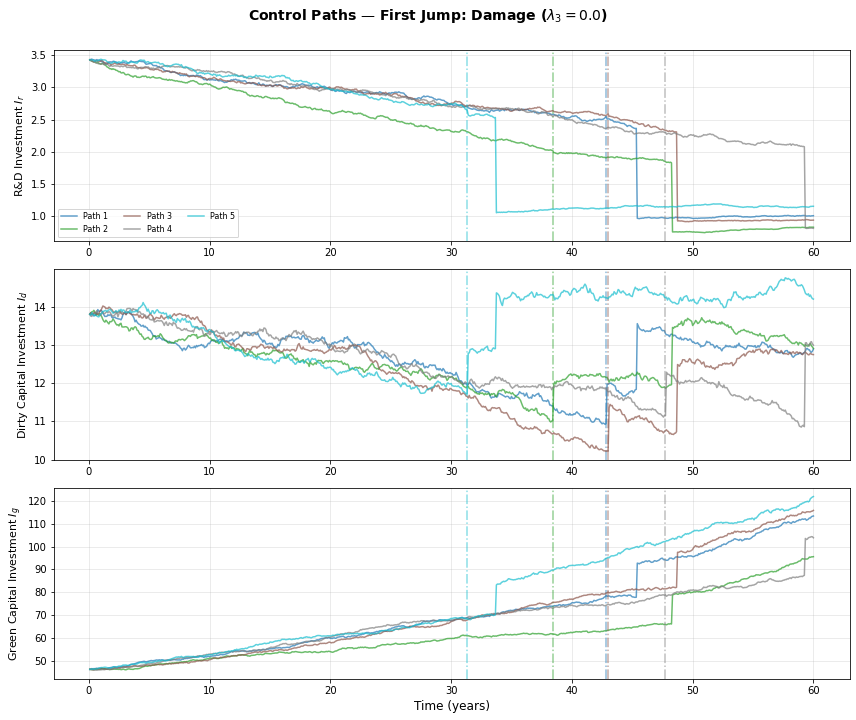


Plotting damage_0.083...
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/controls_paths_damage_0.083.png


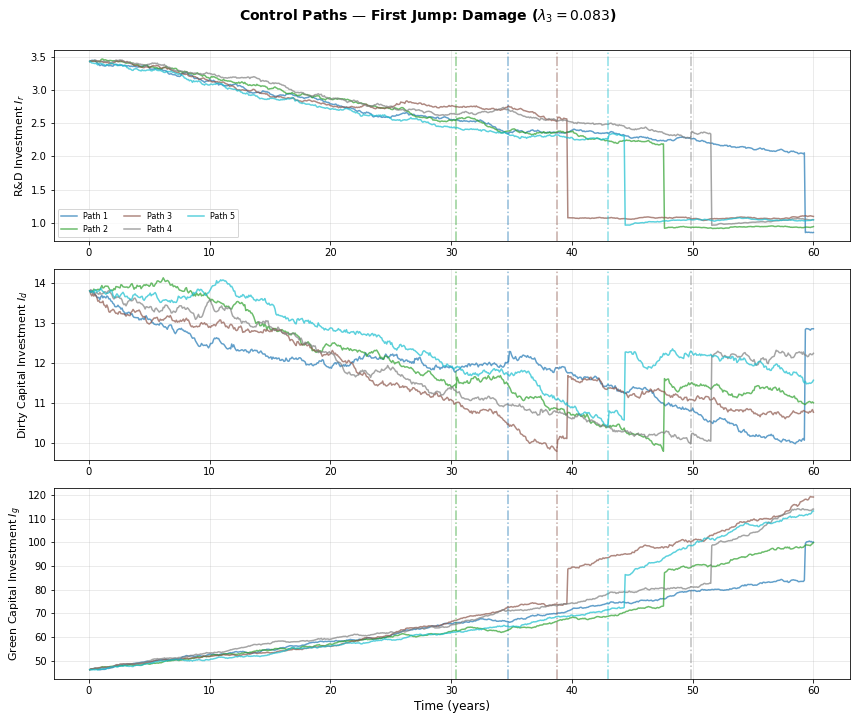


Plotting damage_0.167...
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/controls_paths_damage_0.167.png


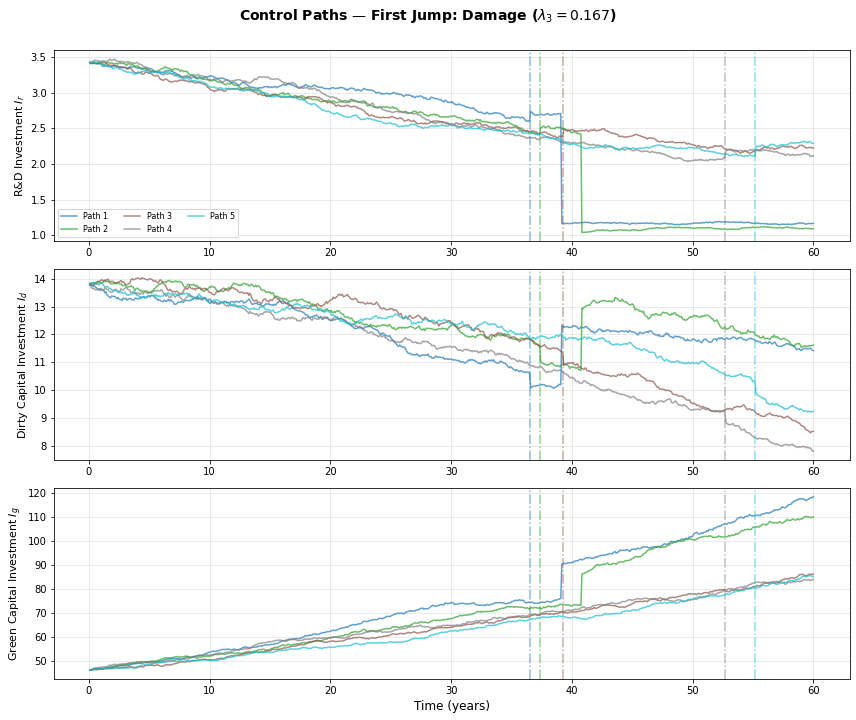


Plotting damage_0.25...
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/controls_paths_damage_0.25.png


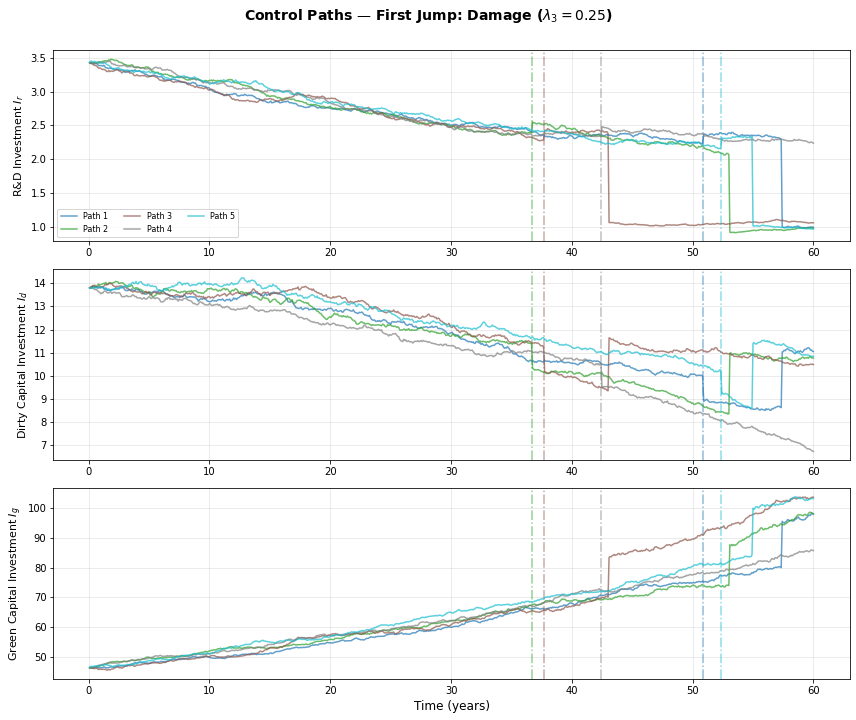


Plotting damage_0.333...
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/controls_paths_damage_0.333.png


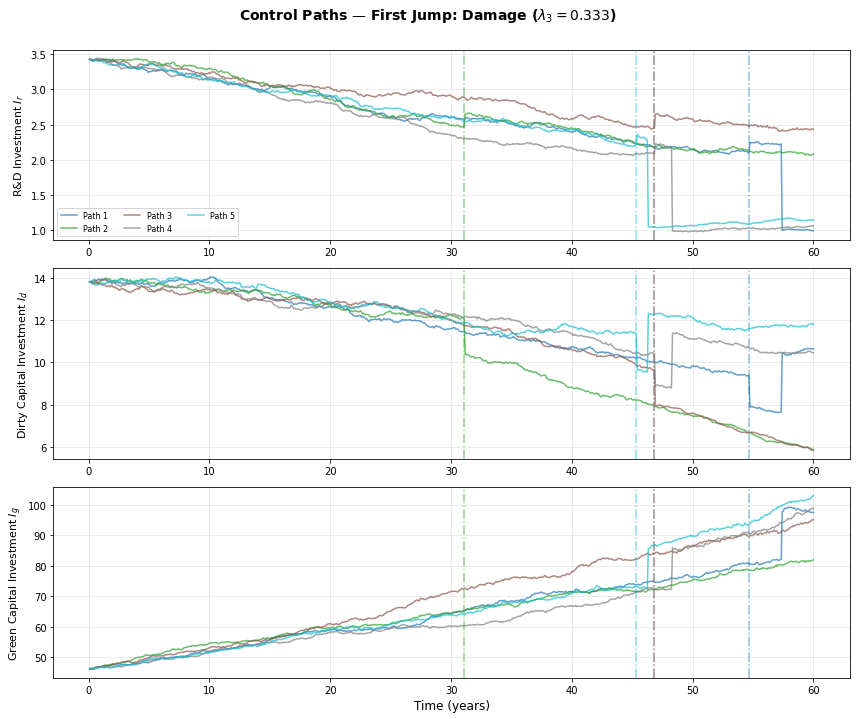


Plotting tech_interm...
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/controls_paths_tech_interm.png


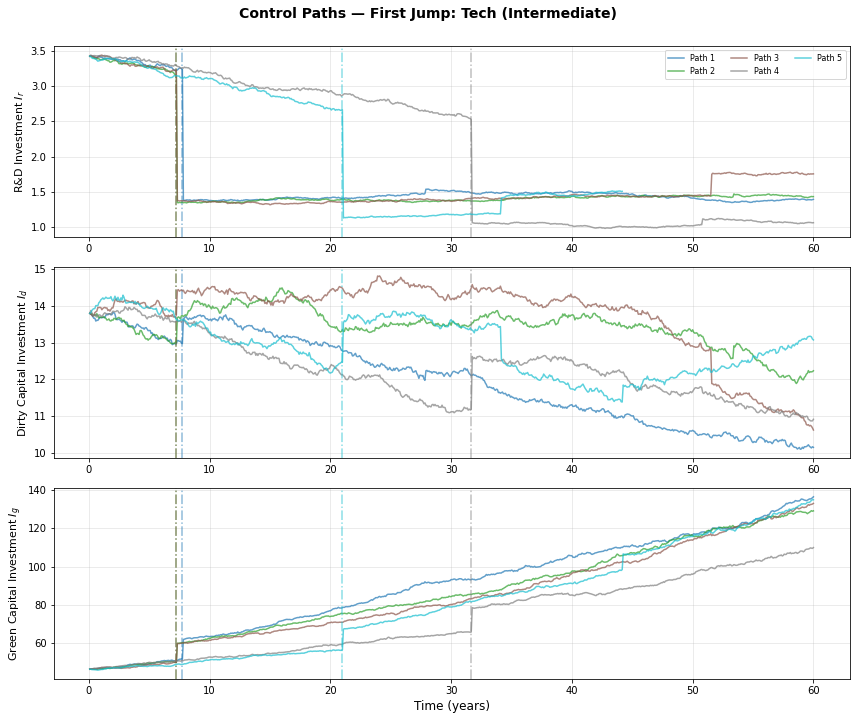


Plotting tech_post...
Saved: /project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4/controls_paths_tech_post.png


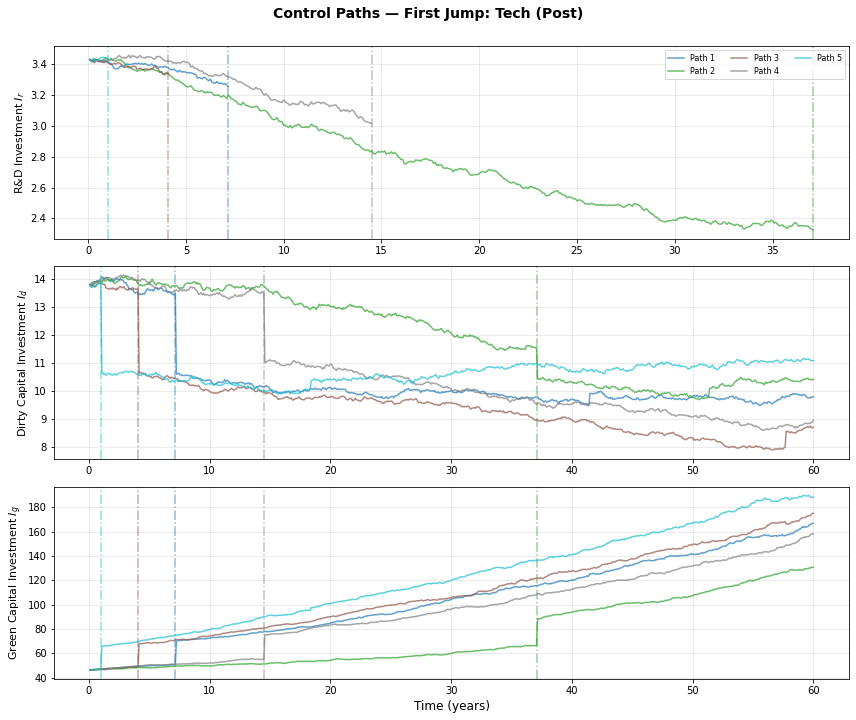


All plots complete!


In [3]:
# ---------- CONFIG ----------
base_folder = "/project/lhansen/Cap_damage/TwoStageTechJump_FOCIr_orignal/SimulationResults/paths_ξ_148.4"
seed_min, seed_max = 1, 100
save_fig = True
LAMBDA3_ROUND = 3          # round λ3 values to group close floats
N_PATHS_PER_TYPE = 5     # number of paths to plot per jump type
# ----------------------------

def load_arrays(folder, seed):
    """Load all necessary arrays for a given seed."""
    D   = np.load(os.path.join(folder, f"damage_state_array_{seed}.npy"))
    T   = np.load(os.path.join(folder, f"tech_state_array_{seed}.npy"))
    Ir  = np.load(os.path.join(folder, f"I_r_array_{seed}.npy"))
    Id  = np.load(os.path.join(folder, f"I_d_array_{seed}.npy"))
    Ig  = np.load(os.path.join(folder, f"I_g_array_{seed}.npy"))
    G3  = np.load(os.path.join(folder, f"gamma3_array_{seed}.npy"))
    return D, T, Ir, Id, Ig, G3

# Collect paths grouped by first jump type
# Jump types: 
#   - 'damage_X.XXX' for damage jumps (5 types based on λ3)
#   - 'tech_interm' for tech jump 0→1
#   - 'tech_post' for tech jump 0→2
paths_by_jump_type = defaultdict(list)

print("Collecting paths and identifying first jumps...")
for seed in range(seed_min, seed_max + 1):
    try:
        D, T, Ir, Id, Ig, G3 = load_arrays(base_folder, seed)
    except FileNotFoundError:
        print(f"[Seed {seed:03d}] missing files, skipping.")
        continue

    n_paths, T_len = D.shape
    
    for path_idx in range(n_paths):
        d = D[path_idx]
        t = T[path_idx]
        
        # Find first damage jump (0 → 1)
        damage_trans = np.where((d[:-1] == 0) & (d[1:] == 1))[0]
        first_damage_time = damage_trans[0] + 1 if damage_trans.size > 0 else np.inf
        
        # Find first tech jump (0 → 1 or 0 → 2)
        tech_trans = np.where((t[:-1] == 0) & (t[1:] > 0))[0]
        first_tech_time = tech_trans[0] + 1 if tech_trans.size > 0 else np.inf
        
        # Determine which jump comes first
        if first_damage_time == np.inf and first_tech_time == np.inf:
            continue  # No jumps in this path
        
        if first_damage_time < first_tech_time:
            # Damage jump comes first
            jump_time = int(first_damage_time)
            lam = G3[path_idx, jump_time]
            
            if not np.isfinite(lam):
                continue
            
            lam_key = round(float(lam), LAMBDA3_ROUND) if LAMBDA3_ROUND is not None else float(lam)
            jump_type = f"damage_{lam_key}"
            
        elif first_tech_time < first_damage_time:
            # Tech jump comes first
            jump_time = int(first_tech_time)
            tech_state_after = t[jump_time]
            
            if tech_state_after == 1:
                jump_type = "tech_interm"
            elif tech_state_after == 2:
                jump_type = "tech_post"
            else:
                continue  # Unexpected state
        else:
            continue  # Should not happen
        
        # Store the full control paths
        paths_by_jump_type[jump_type].append({
            'seed': seed,
            'path_idx': path_idx,
            'jump_time': jump_time,
            'jump_type': jump_type,
            'Ir': Ir[path_idx, :],
            'Id': Id[path_idx, :],
            'Ig': Ig[path_idx, :]
        })

# Sort jump types (damage types by λ3, then tech types)
damage_types = sorted([k for k in paths_by_jump_type.keys() if k.startswith('damage_')])
tech_types = sorted([k for k in paths_by_jump_type.keys() if k.startswith('tech_')])
all_jump_types = damage_types + tech_types

print(f"\nFound {len(all_jump_types)} unique jump types:")
print("\nDamage jumps:")
for jt in damage_types:
    lam_val = jt.replace('damage_', '')
    print(f"  Damage (λ3={lam_val}): {len(paths_by_jump_type[jt])} paths")
print("\nTech jumps:")
for jt in tech_types:
    print(f"  {jt.replace('tech_', '').capitalize()}: {len(paths_by_jump_type[jt])} paths")

# Sample paths for plotting
np.random.seed(42)  # For reproducibility
sampled_paths = {}

for jump_type in all_jump_types:
    available = paths_by_jump_type[jump_type]
    n_available = len(available)
    
    if n_available <= N_PATHS_PER_TYPE:
        sampled_paths[jump_type] = available
        print(f"\n{jump_type}: Using all {n_available} paths")
    else:
        indices = np.random.choice(n_available, N_PATHS_PER_TYPE, replace=False)
        sampled_paths[jump_type] = [available[i] for i in indices]
        print(f"\n{jump_type}: Sampled {N_PATHS_PER_TYPE} paths from {n_available}")

# Plotting function - now plots all three controls in subplots
def plot_all_controls(jump_type, paths, time_step=1/12):
    """
    Plot all three controls (Ir, Id, Ig) for the same paths in subplots.
    
    Parameters:
    - jump_type: str, type of jump
    - paths: list of path dictionaries
    - time_step: float, time step in years (default 1/12 for monthly)
    """
    
    if len(paths) == 0:
        return
    
    # Create figure with 3 subplots
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    
    # Color map for different paths
    colors = plt.cm.tab10(np.linspace(0, 1, len(paths)))
    
    control_keys = ['Ir', 'Id', 'Ig']
    control_names = ['R&D Investment $I_r$', 
                     'Dirty Capital Investment $I_d$', 
                     'Green Capital Investment $I_g$']
    
    for ax_idx, (control_key, control_name) in enumerate(zip(control_keys, control_names)):
        ax = axes[ax_idx]
        
        for i, path_data in enumerate(paths):
            control_path = path_data[control_key]
            jump_time = path_data['jump_time']
            
            # Create time axis in years
            T_len = len(control_path)
            time_years = np.arange(T_len) * time_step
            
            # Plot the control path
            ax.plot(time_years, control_path, 
                   alpha=0.7, linewidth=1.5, color=colors[i],
                   label=f"Path {i+1}")
            
            # Add vertical dot-dash line at jump time
            jump_time_years = jump_time * time_step
            ax.axvline(x=jump_time_years, color=colors[i], 
                      linestyle='-.', linewidth=1.5, alpha=0.5)
        
        ax.set_ylabel(control_name, fontsize=11)
        ax.grid(True, alpha=0.3)
        
        # Only show legend on first subplot
        if ax_idx == 0:
            ax.legend(loc='best', fontsize=8, ncol=3)
        
        # Only show x-label on bottom subplot
        if ax_idx == 2:
            ax.set_xlabel("Time (years)", fontsize=12)
    
    # Create title based on jump type
    if jump_type.startswith('damage_'):
        lam_val = jump_type.replace('damage_', '')
        title = f"Control Paths — First Jump: Damage ($\lambda_3 = {lam_val}$)"
    elif jump_type == 'tech_interm':
        title = "Control Paths — First Jump: Tech (Intermediate)"
    elif jump_type == 'tech_post':
        title = "Control Paths — First Jump: Tech (Post)"
    else:
        title = f"Control Paths — First Jump: {jump_type}"
    
    fig.suptitle(title, fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    
    if save_fig:
        filename = f"controls_paths_{jump_type}.png"
        out_path = os.path.join(base_folder, filename)
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {out_path}")
    
    plt.show()
    plt.close()

# Plot for each jump type
print("\n" + "="*60)
print("Plotting control paths for each jump type...")
print("="*60)

for jump_type in all_jump_types:
    if jump_type in sampled_paths:
        print(f"\nPlotting {jump_type}...")
        plot_all_controls(jump_type, sampled_paths[jump_type])

print("\nAll plots complete!")